In [101]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(cairo)

ERROR: Error in library(cairo): there is no package called ‘cairo’


In [36]:
composite_df <- read.csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/combined_composite_test.csv')

In [72]:
options(repr.plot.width = 5, repr.plot.height = 3)

In [109]:
thresholds <- c(0.5, 0.7, 0.9)

# Convert to long format
long_df <- composite_df %>%
  pivot_longer(
    cols = starts_with("score_"),
    names_to = "celltype",
    names_prefix = "score_",
    values_to = "score"
  )

# Count genes above each threshold
count_df <- bind_rows(
  lapply(thresholds, function(t) {
    long_df %>%
      group_by(celltype) %>%
      summarise(count = sum(score > t), .groups = "drop") %>%
      mutate(threshold = factor(t, levels = thresholds))
  })
)

# Ensure correct ordering
count_df$threshold <- factor(count_df$threshold, levels = c("0.5", "0.7", "0.9"))

# Plot
p <- ggplot(count_df,
       aes(x = celltype, y = count, fill = threshold)) +
  geom_col(
    width = 1,
    position = position_dodge(width = 1),
    color = "black",
    linewidth = 0.3,
    linejoin = "mitre"
  ) +
  scale_fill_manual(
    values = c(
      "0.5" = "#c7eae5",  
      "0.7" = "#35978f", 
      "0.9" = "#003c30"
    )
  ) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(
    x = NULL,
    y = "Genes Above Threshold",
    fill = "Threshold"
  ) +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = -30, hjust = 0, size = 20),
    axis.text.y = element_text(size = 15),
    axis.title.y = element_text(size = 20, margin = margin(r = 10)),
    legend.position = "right"
  )

ggsave(
  filename = "/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_mashR_barplot.pdf",
  plot = p,
  width = 5,
  height = 3,
  units = "in",
)

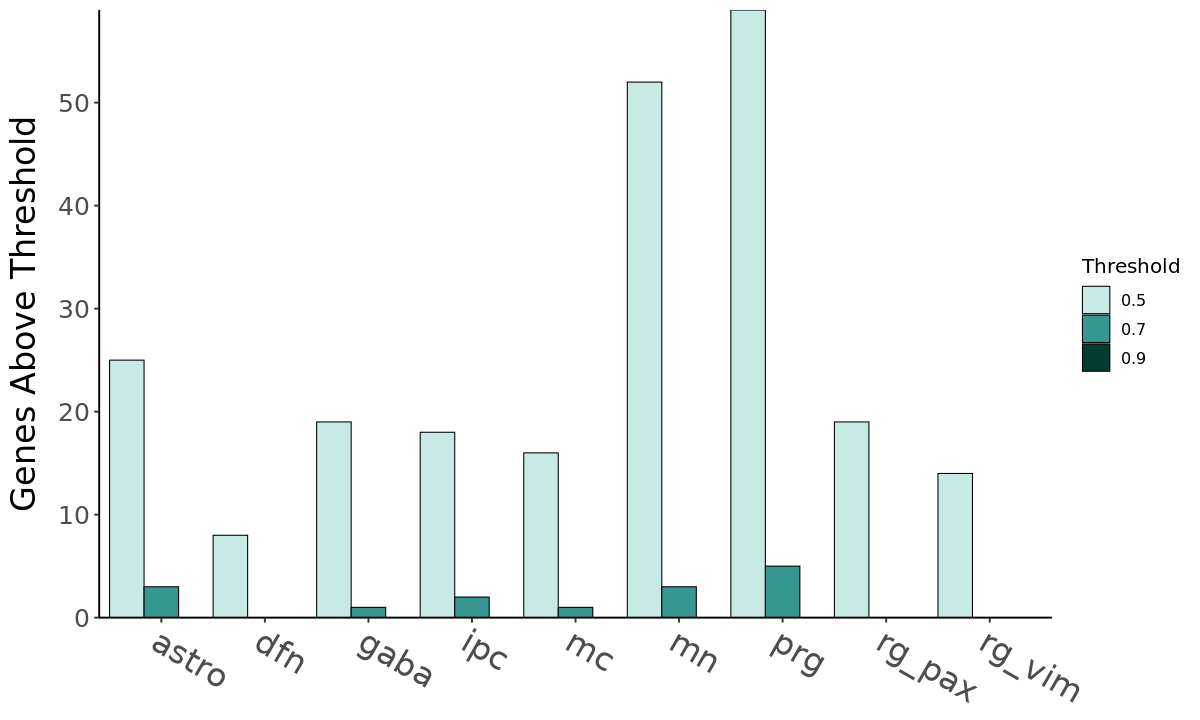

In [110]:
p